In [1]:
# pyright: reportUndefinedVariable=false
# names like sine, explore_data, main_loop, plots, etc. are defined in
# base.ipynb and injected into this kernel's namespace by %run below —
# Pylance can't see across %run, hence this directive to silence the
# (harmless) "undefined variable" warnings it would otherwise raise.
%run base.ipynb

mare


### esperimento Belkin 2020


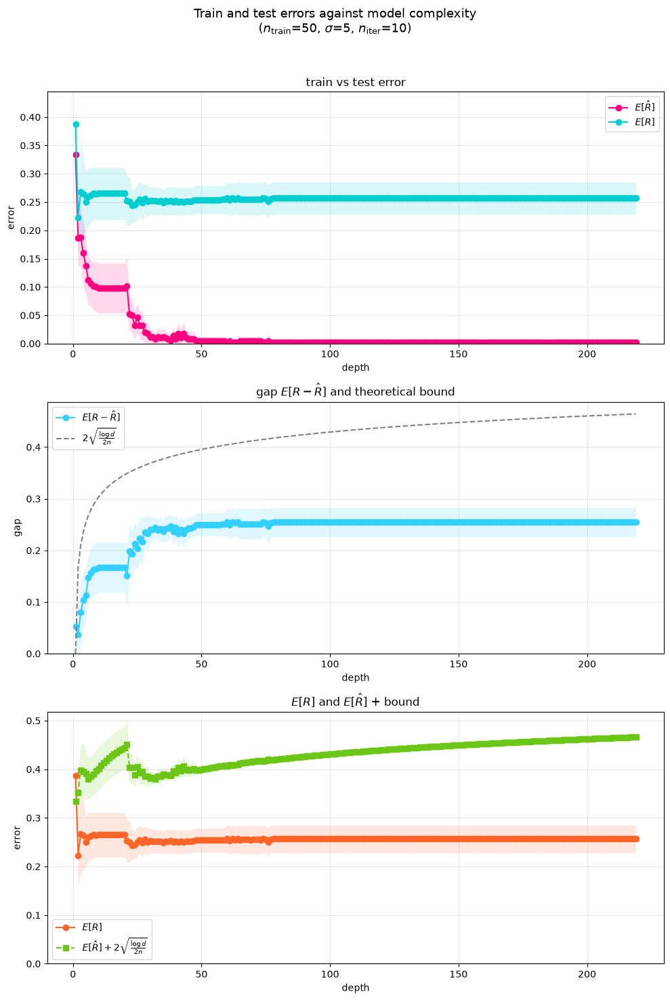

In [2]:
# MODEL
mymodel = RandomForestClassifier

# PARAMETERS
# kept modest: the hybrid complexity measure fits ~220 (depth, n_estimators)
# combinations (see get_depths_list), and forests with up to 200 trees are
# much slower to fit/score than a single tree — scale T/n_test/N up once
# this runs comfortably
N = 2_000
n_test = 20_000
n = 50
noise_std = 5
T = 10

# build test set
x_test = sample_x(n_test, N)
y_test = sample_y(x = x_test, f = centered_parabola, sigma = noise_std)

# build models and do plots: complexity = (single-tree depth, then n_trees)
hat_Rs, Rs, gaps, std_hat_Rs, std_Rs, std_gaps, predictions, x, y, x_grid = main_loop(x_test, y_test, n_train = n, sigma = noise_std, num_iter = T, model = mymodel, supp_size=N)
plots(hat_Rs, Rs, gaps, std_hat_Rs=std_hat_Rs, std_Rs=std_Rs, std_gaps=std_gaps, n_train = n, sigma = noise_std, num_iter= T, model = mymodel)

In [3]:
# show animated function

animation = animate_learned_function(model = mymodel, n_train = n, best_pred = predictions,
                         best_x = x, best_y = y, x_grid = x_grid)
HTML(animation.to_jshtml())